# CS-378: Design and Analysis of Algorithms — Semester Project
## Notebook 2: Apriori (Baseline) + Two Optimization Strategies

**Group Members:** Bilal Ahmad Sheikh (2023162), Muhammad Muzzammil Idrees (2023481)  
**Institution:** Ghulam Ishaq Khan Institute of Engineering Sciences and Technology

---

### Algorithms Implemented in This Notebook

| Algorithm | Paper | Role |
|-----------|-------|------|
| **Apriori Baseline** | Agrawal & Srikant (1994), VLDB | Baseline — breadth-first, generate-and-test, full DB scan per level |
| **Apriori + HashTree** | Park, Chen & Yu (1995), SIGMOD (DHP) | Optimization 1 — hash tree reduces candidate lookup from O(C) to O(1) per transaction |
| **Apriori + Tidset (ECLAT-style)** | Zaki et al. (1997), KDD | Optimization 2 — vertical format, support = tidset intersection, zero DB rescans |

### Bottleneck Analysis (Justification for Optimizations)

The two fundamental bottlenecks of Apriori on dense datasets are:
1. **Repeated full database scans** — at each level k, the entire DB is scanned to count support of C_k candidates. Time complexity: O(|DB| × |C_k|) per level.
2. **Exponential candidate generation** — in dense datasets (Chess: 75 items, ~86% avg density), the number of candidates explodes since nearly all subsets are frequent.

- **HashTree** targets bottleneck (1): Instead of linear scan over candidates per transaction, candidates are stored in a hash tree and a transaction is hashed into the relevant bucket → O(1) average lookup per candidate level.
- **Tidset** targets bottleneck (1) completely: support(X ∪ {j}) = |tidset(X) ∩ tidset(j)|. No database scans at all beyond level 1.

---
## Section 1: Setup — Load Data from Notebook 1

In [2]:
import os
import gc
import sys
import time
import math
import pickle
import signal
import tracemalloc
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict, Counter
from tabulate import tabulate

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [3]:
# ─── Load the data bundle saved by Notebook 1 ────────────────────────────────
BUNDLE_PATH = '/content/drive/MyDrive/CS378_FIM_Project/data_bundle.pkl'

assert os.path.exists(BUNDLE_PATH), (
    f'Bundle not found at {BUNDLE_PATH}. Run Notebook 1 first.'
)

with open(BUNDLE_PATH, 'rb') as f:
    bundle = pickle.load(f)

datasets           = bundle['datasets']            # horizontal: list of frozenset
vertical_datasets  = bundle['vertical_datasets']   # item -> set of TIDs
MIN_SUP_THRESHOLDS = bundle['MIN_SUP_THRESHOLDS']  # [0.50, 0.60, 0.70, 0.80, 0.90]

# ─── Configuration ────────────────────────────────────────────────────────────
N_TRIALS      = 3          # number of repetitions per experiment (averaged)
TIMEOUT_SEC   = 120        # seconds before we skip an (algo, dataset, threshold) combo
MAX_ITEMSET_K = 10         # safety cap on itemset depth (prevents infinite loop)

# Dense datasets are hard at low thresholds — restrict Apriori Baseline on
# large datasets to avoid OOM.  Tidset and HashTree can handle more.
BASELINE_SKIP = {
    # (dataset, min_sup) combos to skip for the BASELINE only
    ('accidents', 0.50), ('accidents', 0.60),
    ('connect',   0.50),
}

print('Data bundle loaded successfully.')
for name, txns in datasets.items():
    print(f'  [{name}]  {len(txns):,} transactions, '
          f'{len(vertical_datasets[name])} unique items')
print(f'\nThresholds : {MIN_SUP_THRESHOLDS}')
print(f'Trials     : {N_TRIALS}')
print(f'Timeout    : {TIMEOUT_SEC}s per run')


Data bundle loaded successfully.
  [chess]  3,196 transactions, 75 unique items
  [connect]  67,557 transactions, 129 unique items
  [accidents]  340,183 transactions, 468 unique items

Thresholds : [0.5, 0.6, 0.7, 0.8, 0.9]
Trials     : 3
Timeout    : 120s per run


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Section 2: Measurement Utilities

In [5]:
# ─── Timing + Memory Measurement ─────────────────────────────────────────────

class TimeoutError(Exception):
    pass

def _timeout_handler(signum, frame):
    raise TimeoutError('Execution exceeded timeout')


def measure_run(func, *args, timeout=TIMEOUT_SEC, **kwargs):
    """
    Run func(*args, **kwargs) with timeout, measuring:
      - wall-clock time (ms)
      - peak RAM usage (MB) via tracemalloc
    Returns: (result, time_ms, peak_mb) or (None, None, None) on timeout/error
    """
    # Register SIGALRM timeout (Linux/Colab only)
    try:
        signal.signal(signal.SIGALRM, _timeout_handler)
        signal.alarm(timeout)
    except (AttributeError, OSError):
        pass  # Windows doesn't support SIGALRM

    gc.collect()
    tracemalloc.start()
    t0 = time.perf_counter()
    result = None
    timed_out = False

    try:
        result = func(*args, **kwargs)
    except TimeoutError:
        timed_out = True
    except MemoryError:
        timed_out = True
        print('    [MemoryError — skipping]')
    except Exception as e:
        print(f'    [ERROR: {e}]')
        timed_out = True
    finally:
        t1 = time.perf_counter()
        _, peak_bytes = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        try:
            signal.alarm(0)
        except (AttributeError, OSError):
            pass

    if timed_out:
        return None, None, None

    time_ms  = (t1 - t0) * 1000.0
    peak_mb  = peak_bytes / (1024 ** 2)
    return result, time_ms, peak_mb


def run_experiment(func, trials, *args, timeout=TIMEOUT_SEC, **kwargs):
    """
    Run func N times, return averaged metrics.
    Returns dict with keys: time_ms, peak_mb, result (from last run),
                            timed_out (bool)
    """
    times, mems = [], []
    last_result = None
    for trial in range(trials):
        res, t, m = measure_run(func, *args, timeout=timeout, **kwargs)
        if res is None:
            return {'time_ms': None, 'peak_mb': None,
                    'result': None, 'timed_out': True}
        times.append(t)
        mems.append(m)
        last_result = res
    return {
        'time_ms':   round(np.mean(times), 2),
        'peak_mb':   round(np.mean(mems),  2),
        'result':    last_result,
        'timed_out': False,
    }


print('Measurement utilities defined.')

Measurement utilities defined.


In [6]:
def _generate_candidates(L_prev_frozen, k):
    """
    Optimized candidate generation using sorted prefix join.
    For each frequent (k-1)-itemset A, find all frequent (k-1)-itemsets B
    where B shares the SAME first k-2 items as A (sorted), and B's last
    item > A's last item. Their union is a valid k-candidate.

    Then prune: verify all (k-1)-subsets are in L_prev_frozen.

    This is O(|L_k| * avg_matches) instead of O(|L_k|^2).
    """
    # Build prefix index: first (k-2) items -> list of (last_item, frozenset)
    from collections import defaultdict
    prefix_index = defaultdict(list)
    for fs in L_prev_frozen:
        items  = tuple(sorted(fs))
        prefix = items[:-1]          # first k-2 items
        last   = items[-1]
        prefix_index[prefix].append((last, fs))

    # Sort each bucket by last item for efficient pairing
    for prefix in prefix_index:
        prefix_index[prefix].sort(key=lambda x: x[0])

    candidates = set()
    for prefix, entries in prefix_index.items():
        for i in range(len(entries)):
            for j in range(i + 1, len(entries)):
                last_i, fs_i = entries[i]
                last_j, fs_j = entries[j]
                # last_j > last_i guaranteed by sort
                candidate = fs_i | frozenset([last_j])

                # Apriori pruning: all (k-1)-subsets must be frequent
                # We already know fs_i and fs_j are in L_prev.
                # Only need to check remaining (k-2) subsets.
                items_c = sorted(candidate)
                valid   = True
                for m in range(len(items_c) - 2):
                    # drop item at position m (not the last two — those are fs_i, fs_j)
                    sub = frozenset(items_c[:m] + items_c[m+1:])
                    if sub not in L_prev_frozen:
                        valid = False
                        break
                if valid:
                    candidates.add(candidate)

    return candidates


# Unit test
_L2 = {frozenset([1,2]), frozenset([1,3]), frozenset([2,3]), frozenset([1,5])}
_C3 = _generate_candidates(_L2, 3)
assert frozenset([1,2,3]) in _C3, 'Should generate {1,2,3}'
assert frozenset([1,2,5]) not in _C3, 'Should NOT generate {1,2,5}'
print(f'_generate_candidates unit test PASSED. Generated: {[set(x) for x in _C3]}')

_generate_candidates unit test PASSED. Generated: [{1, 2, 3}]


---
## Section 3: Apriori Baseline
### Based on: Agrawal & Srikant (1994). *Fast Algorithms for Mining Association Rules*. VLDB.

#### Algorithm Description
1. Scan DB → get frequent 1-itemsets L₁
2. Loop: generate candidates C_{k+1} by self-joining L_k (F_{k-1}-prefix merge)
3. Prune C_{k+1}: remove any candidate whose (k)-subset is not in L_k
4. Scan DB → count support of each candidate → retain frequent ones as L_{k+1}
5. Stop when L_k is empty

**Complexity:** O(2^|I|) worst case; O(|DB| × |C_k|) per level for support counting.

In [7]:
# ─── Apriori Baseline — Agrawal & Srikant (1994) ─────────────────────────────

def apriori_baseline(transactions, min_sup_frac):
    """
    Apriori algorithm — Agrawal & Srikant (1994).
    Candidate generation: brute-force union of all (k-1)-itemset pairs.
    Support counting: full horizontal DB scan per level.
    """
    n_tx              = len(transactions)
    min_count         = math.ceil(min_sup_frac * n_tx)
    frequent_itemsets = {}
    candidates_total  = 0
    level_stats       = []

    # Level 1
    item_counts = Counter(item for tx in transactions for item in tx)
    L_prev = {frozenset([item]): cnt
              for item, cnt in item_counts.items()
              if cnt >= min_count}
    candidates_total += len(item_counts)
    level_stats.append((1, len(item_counts), len(L_prev)))
    frequent_itemsets.update(L_prev)

    k = 1
    while L_prev and k < MAX_ITEMSET_K:
        k += 1

        candidates = _generate_candidates(set(L_prev.keys()), k)
        candidates_total += len(candidates)

        if not candidates:
            break

        # Full DB scan for support counting
        cand_counts = {c: 0 for c in candidates}
        for tx in transactions:
            for c in candidates:
                if c.issubset(tx):
                    cand_counts[c] += 1

        L_prev = {c: cnt for c, cnt in cand_counts.items()
                  if cnt >= min_count}
        frequent_itemsets.update(L_prev)
        level_stats.append((k, len(candidates), len(L_prev)))

    return frequent_itemsets, candidates_total, level_stats


# Sanity test on toy data
_toy = [
    frozenset([1, 2, 5]),
    frozenset([2, 4]),
    frozenset([2, 3]),
    frozenset([1, 2, 4]),
    frozenset([1, 3]),
    frozenset([2, 3]),
    frozenset([1, 3]),
    frozenset([1, 2, 3, 5]),
    frozenset([1, 2, 3])
]
_fi, _ct, _ls = apriori_baseline(_toy, min_sup_frac=0.22)
print(f'Baseline sanity: {len(_fi)} frequent itemsets, {_ct} candidates')
print(f'Level stats: {_ls}')
assert len(_fi) >= 8, 'Baseline toy test failed'
print('[PASSED]')


Baseline sanity: 13 frequent itemsets, 17 candidates
Level stats: [(1, 5, 5), (2, 10, 6), (3, 2, 2)]
[PASSED]


---
## Section 4: Optimization 1 — HashTree Candidate Lookup
### Based on: Park, Chen & Yu (1995). *An Effective Hash-Based Algorithm for Mining Association Rules*. SIGMOD.

#### Optimization Description
**Problem in Baseline:** For each transaction `tx` and each candidate `c`, we check `c.issubset(tx)` — this is O(|C_k|) per transaction. For large candidate sets this is the dominant cost.

**HashTree Solution:** Store candidates in a hash tree (a trie where each node is a hash bucket). To count support, hash a transaction's k-subsets directly to the matching bucket — only candidates in that bucket need to be compared. Average complexity per transaction drops from O(|C_k|) to O(|tx|^k / branching_factor).

**Implementation:** We implement a hash tree where:
- Leaf nodes store lists of candidates
- Internal nodes are dicts (hash buckets) keyed by `item_id % branch_factor`
- Support counting: generate all k-subsets of each transaction, hash each subset into the tree, increment matching candidates

In [8]:
# ─── Apriori + HashTree — Park, Chen & Yu (1995) ─────────────────────────────
# The key optimization: build an inverted index from each transaction's
# items to candidates. For each transaction tx, only candidates that are
# SUBSETS of tx need to be counted. We precompute for each item which
# candidates contain it, then intersect per transaction.
# This avoids the O(|C_k|) linear scan per transaction.

class HashTree:
    """
    Hash-partitioned candidate storage.

    Core idea from Park et al. 1995:
    - Store candidates in hash buckets keyed by first item % branch_factor
    - For each transaction, only probe buckets reachable from tx items
    - Eliminates checking candidates that share no items with transaction
    """
    def __init__(self, candidates, branch_factor=50):
        self.bf          = branch_factor
        self.buckets     = defaultdict(list)   # first_item_hash -> [frozenset]
        self.counts      = {}                  # frozenset -> int

        for c in candidates:
            items = sorted(c)
            key   = items[0] % self.bf         # hash on FIRST item only
            self.buckets[key].append(c)
            self.counts[c] = 0

        # Precompute: item -> set of candidates containing that item
        # Used to quickly find which candidates a transaction could satisfy
        self.item_to_cands = defaultdict(list)
        for c in candidates:
            for item in c:
                self.item_to_cands[item].append(c)

    def count_transactions(self, transactions, k):
        """
        For each transaction:
        1. Find candidates whose FIRST item (sorted) is in the transaction
           by probing only the relevant hash buckets
        2. Check issubset only for those candidates

        Speedup vs baseline: skips all candidates whose first item
        is not in the transaction — reduces comparisons significantly
        for dense datasets where items are concentrated.
        """
        tx_items_list = [sorted(tx) for tx in transactions]

        for tx_items in tx_items_list:
            if len(tx_items) < k:
                continue
            tx_set = frozenset(tx_items)

            # Only probe buckets for items that appear in this transaction
            seen_keys = set()
            for item in tx_items:
                key = item % self.bf
                if key in seen_keys:
                    continue
                seen_keys.add(key)
                if key in self.buckets:
                    for cand in self.buckets[key]:
                        if cand.issubset(tx_set):
                            self.counts[cand] += 1

    def get_frequent(self, min_count):
        return {c: cnt for c, cnt in self.counts.items()
                if cnt >= min_count}


def apriori_hashtree(transactions, min_sup_frac):
    """
    Apriori with HashTree — Park, Chen & Yu (1995).
    Candidate generation: _generate_candidates (same as baseline).
    Support counting: hash-bucket pruning reduces candidates checked per tx.
    """
    n_tx              = len(transactions)
    min_count         = math.ceil(min_sup_frac * n_tx)
    frequent_itemsets = {}
    candidates_total  = 0
    level_stats       = []

    # Level 1
    item_counts = Counter(item for tx in transactions for item in tx)
    L_prev = {frozenset([item]): cnt
              for item, cnt in item_counts.items()
              if cnt >= min_count}
    candidates_total += len(item_counts)
    level_stats.append((1, len(item_counts), len(L_prev)))
    frequent_itemsets.update(L_prev)

    k = 1
    while L_prev and k < MAX_ITEMSET_K:
        k += 1

        candidates = _generate_candidates(set(L_prev.keys()), k)
        candidates_total += len(candidates)

        if not candidates:
            break

        tree = HashTree(candidates)
        tree.count_transactions(transactions, k)

        L_prev = tree.get_frequent(min_count)
        frequent_itemsets.update(L_prev)
        level_stats.append((k, len(candidates), len(L_prev)))

    return frequent_itemsets, candidates_total, level_stats


# Sanity test
_fi_ht, _ct_ht, _ = apriori_hashtree(_toy, min_sup_frac=0.22)
assert set(_fi.keys()) == set(_fi_ht.keys()), \
    f'HT mismatch — only_base={set(_fi.keys())-set(_fi_ht.keys())} '\
    f'only_ht={set(_fi_ht.keys())-set(_fi.keys())}'
for fs in _fi:
    assert _fi[fs] == _fi_ht[fs], \
        f'Count wrong {set(fs)}: base={_fi[fs]} ht={_fi_ht[fs]}'
print(f'HashTree sanity PASSED — {len(_fi_ht)} frequent itemsets.')

HashTree sanity PASSED — 13 frequent itemsets.


---
## Section 5: Optimization 2 — Tidset (Vertical Format) Support Counting
### Based on: Zaki et al. (1997). *New Algorithms for Fast Discovery of Association Rules*. KDD.

#### Optimization Description
**Problem in Baseline:** Each level requires a full scan of all transactions to compute support.

**Tidset Solution:** Store each item's TID-set (set of transaction IDs). Support counting becomes a set intersection:
$$\text{support}(X \cup Y) = |\text{tidset}(X) \cap \text{tidset}(Y)|$$

After level 2 all support counts are computed via intersection — **zero DB scans**. For dense datasets with large tidsets, Python `set.intersection()` is implemented in C and is extremely fast.

**Time complexity:** O(N) for level 1 (build tidsets), then O(|tidset| × |candidates|) for deeper levels — no factor of |DB| per level.

In [25]:
def _make_bitset(tids, n_tx):
    ba = bytearray((n_tx + 7) // 8)
    for tid in tids:
        ba[tid >> 3] |= (1 << (tid & 7))
    return ba

def _bitset_and(ba1, ba2):
    return bytearray(a & b for a, b in zip(ba1, ba2))

def _bitset_count(ba):
    return sum(bin(b).count('1') for b in ba)

def apriori_tidset(transactions, min_sup_frac, prebuilt_vertical=None):
    n_tx      = len(transactions)
    min_count = math.ceil(min_sup_frac * n_tx)
    frequent_itemsets = {}
    candidates_total  = 0
    level_stats       = []

    if prebuilt_vertical is not None:
        L_tidsets = {frozenset([item]): _make_bitset(tids, n_tx)
                     for item, tids in prebuilt_vertical.items()
                     if len(tids) >= min_count}
        all_1 = len(prebuilt_vertical)
    else:
        raw = defaultdict(set)
        for tid, tx in enumerate(transactions):
            for item in tx:
                raw[frozenset([item])].add(tid)
        L_tidsets = {fs: _make_bitset(tids, n_tx)
                     for fs, tids in raw.items()
                     if len(tids) >= min_count}
        all_1 = len(raw)

    L_prev = {fs: _bitset_count(bs) for fs, bs in L_tidsets.items()}
    candidates_total += all_1
    level_stats.append((1, all_1, len(L_prev)))
    frequent_itemsets.update(L_prev)

    k = 1
    while L_prev and k < MAX_ITEMSET_K:
        k += 1
        candidates = _generate_candidates(set(L_tidsets.keys()), k)
        candidates_total += len(candidates)
        if not candidates:
            level_stats.append((k, 0, 0))
            break

        new_tidsets = {}
        for candidate in candidates:
            items = sorted(candidate)
            sub1  = frozenset(items[:-1])
            sub2  = frozenset(items[:-2] + [items[-1]])
            if sub1 not in L_tidsets or sub2 not in L_tidsets:
                continue
            new_bs = _bitset_and(L_tidsets[sub1], L_tidsets[sub2])
            cnt    = _bitset_count(new_bs)
            if cnt >= min_count:
                new_tidsets[candidate] = new_bs

        del L_tidsets
        gc.collect()

        if not new_tidsets:
            level_stats.append((k, len(candidates), 0))
            break

        L_tidsets = new_tidsets
        L_prev    = {fs: _bitset_count(bs) for fs, bs in new_tidsets.items()}
        frequent_itemsets.update(L_prev)
        level_stats.append((k, len(candidates), len(L_prev)))

    return frequent_itemsets, candidates_total, level_stats

---
## Section 6: Cross-Validation on Chess Dataset (Small min_sup)

Before running all experiments, validate all three implementations produce **identical frequent itemsets** on Chess at min_sup=0.90 (fast and tractable).

In [26]:
# Run cross-validation on a SMALL threshold first to verify correctness fast
# Chess@90% has too many frequent itemsets for brute-force candidate gen to be quick
# Use 95% for validation (far fewer frequent itemsets = fast)

import time

print('Cross-validating all 3 algorithms on Chess @ min_sup=0.95...')
start_total = time.time()

chess_txns     = datasets['chess']
chess_vertical = vertical_datasets['chess']
VAL_THRESH     = 0.95   # changed from 0.90 to 0.95

print('  Running Apriori Baseline...')
t0 = time.time()
fi_base, _, _ = apriori_baseline(chess_txns, VAL_THRESH)
t1 = time.time()
print(f'  ✓ Baseline finished in {t1 - t0:.2f} seconds.')

print('  Running Apriori HashTree...')
fi_ht,   _, _ = apriori_hashtree(chess_txns, VAL_THRESH)
t2 = time.time()
print(f'  ✓ HashTree finished in {t2 - t1:.2f} seconds.')

print('  Running Apriori Tidset...')
fi_ts,   _, _ = apriori_tidset(chess_txns, VAL_THRESH,
                                prebuilt_vertical=chess_vertical)
t3 = time.time()
print(f'  ✓ Tidset finished in {t3 - t2:.2f} seconds.')

keys_base = set(fi_base.keys())
keys_ht   = set(fi_ht.keys())
keys_ts   = set(fi_ts.keys())

print(f'\n  Baseline  : {len(fi_base)} frequent itemsets')
print(f'  HashTree  : {len(fi_ht)}  frequent itemsets')
print(f'  Tidset    : {len(fi_ts)}  frequent itemsets')

# Support count check
count_ok = True
for fs in keys_base:
    b = fi_base[fs]
    h = fi_ht.get(fs)
    t = fi_ts.get(fs)
    if h != b or t != b:
        print(f'  COUNT MISMATCH {set(fs)}: base={b} ht={h} ts={t}')
        count_ok = False

if keys_base == keys_ht == keys_ts and count_ok:
    print('\n  ✅ All three algorithms produce IDENTICAL results.')
else:
    print(f'  ❌ MISMATCH:')
    print(f'    Baseline-only (missed by HashTree): {len(keys_base - keys_ht)}')
    print(f'    Baseline-only (missed by Tidset)  : {len(keys_base - keys_ts)}')
    print(f'    Extra in HashTree                 : {len(keys_ht - keys_base)}')
    print(f'    Extra in Tidset                   : {len(keys_ts - keys_base)}')

print(f'\n⏱️ Total cell execution time: {time.time() - start_total:.2f} seconds.')

Cross-validating all 3 algorithms on Chess @ min_sup=0.95...
  Running Apriori Baseline...
  ✓ Baseline finished in 0.04 seconds.
  Running Apriori HashTree...
  ✓ HashTree finished in 0.10 seconds.
  Running Apriori Tidset...
  ✓ Tidset finished in 5.36 seconds.

  Baseline  : 77 frequent itemsets
  HashTree  : 77  frequent itemsets
  Tidset    : 77  frequent itemsets

  ✅ All three algorithms produce IDENTICAL results.

⏱️ Total cell execution time: 5.50 seconds.


In [11]:
# ─── TIDSET DEBUG ─────────────────────────────────────────────────────────────
# Run baseline and tidset on Chess@0.90, find exactly what the 457 extras are

chess_txns = datasets['chess']
chess_vert = vertical_datasets['chess']

fi_base, _, _ = apriori_baseline(chess_txns, 0.90)
fi_ts,   _, _ = apriori_tidset(chess_txns, 0.90, prebuilt_vertical=chess_vert)

keys_base = set(fi_base.keys())
keys_ts   = set(fi_ts.keys())

extras = keys_ts - keys_base  # in tidset but NOT in baseline
print(f'Total extras in Tidset: {len(extras)}')
print()

# Show size distribution of extras
from collections import Counter
size_dist = Counter(len(fs) for fs in extras)
print('Size distribution of extra itemsets:')
for size, count in sorted(size_dist.items()):
    print(f'  k={size}: {count} itemsets')

print()
# Show 5 examples of extras with their support counts
print('Sample extras (itemset -> tidset_support):')
for fs in list(extras)[:5]:
    ts_count   = fi_ts[fs]
    # manually verify: count transactions containing this itemset
    true_count = sum(1 for tx in chess_txns if fs.issubset(tx))
    print(f'  {set(fs)}  tidset_says={ts_count}  true_count={true_count}  '
          f'min_count={int(0.90*len(chess_txns))}  '
          f'should_be_frequent={true_count >= int(0.90*len(chess_txns))}')

print()
# Check: are these extras actually frequent according to true count?
false_positives = 0
false_negatives = 0
for fs in extras:
    true_count = sum(1 for tx in chess_txns if fs.issubset(tx))
    if true_count >= int(0.90 * len(chess_txns)):
        false_negatives += 1  # baseline missed it
    else:
        false_positives += 1  # tidset wrongly included it
print(f'Extras that ARE truly frequent (baseline missed): {false_negatives}')
print(f'Extras that are NOT truly frequent (tidset wrong): {false_positives}')

print()
# Show what level they appear at
print('Level distribution of extras:')
for fs in list(extras)[:10]:
    print(f'  k={len(fs)}  {set(fs)}  tidset_count={fi_ts[fs]}')

Total extras in Tidset: 0

Size distribution of extra itemsets:

Sample extras (itemset -> tidset_support):

Extras that ARE truly frequent (baseline missed): 0
Extras that are NOT truly frequent (tidset wrong): 0

Level distribution of extras:


In [12]:
# Find what baseline is missing and why
print('Checking baseline candidate generation...')

# Run baseline with debug — track what gets pruned at each level
chess_txns = datasets['chess']
n_tx = len(chess_txns)
min_count = math.ceil(0.90 * n_tx)

# Take one known-missing itemset and trace it
missing_example = list(keys_base.symmetric_difference(keys_ts) - keys_base)[:3]
for fs in missing_example:
    print(f'\nMissing: {set(fs)}  true_support={sum(1 for tx in chess_txns if fs.issubset(tx))}')
    # Check if all subsets of size k-1 are in baseline result
    k = len(fs)
    for sub in itertools.combinations(sorted(fs), k-1):
        sub_fs = frozenset(sub)
        in_base = sub_fs in fi_base
        true_sup = sum(1 for tx in chess_txns if sub_fs.issubset(tx))
        print(f'  subset {set(sub_fs)}: in_baseline={in_base}, true_sup={true_sup}, frequent={true_sup>=min_count}')

Checking baseline candidate generation...


---
## Section 7: Full Benchmark Experiments

Run all three algorithms across all 3 datasets × 5 thresholds × 3 trials. Results are averaged.

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2 — FULL BENCHMARK (FINAL)
# Includes: previous results + RAM-safe execution + bitset tidset
# RAM limit: skips any combo that would exceed ~4GB peak
# ═══════════════════════════════════════════════════════════════════════════════

import tracemalloc, time, gc, signal, math, itertools, pickle, os
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# ── 1. Previous results (hardcoded from crashed runs) ─────────────────────────
RESULTS = [
    {'Dataset':'chess','Algorithm':'Apriori-Tidset',  'min_sup':0.60,'time_ms':57417.3, 'peak_mb':14192.4,'num_frequent':246864,'candidates':None,'speedup':None,'timed_out':False,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Tidset',  'min_sup':0.70,'time_ms':9835.4,  'peak_mb':2803.6, 'num_frequent':48512, 'candidates':None,'speedup':None,'timed_out':False,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Tidset',  'min_sup':0.80,'time_ms':1664.2,  'peak_mb':533.3,  'num_frequent':8227,  'candidates':None,'speedup':None,'timed_out':False,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Tidset',  'min_sup':0.90,'time_ms':103.0,   'peak_mb':46.5,   'num_frequent':622,   'candidates':None,'speedup':None,'timed_out':False,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-HashTree','min_sup':0.90,'time_ms':1988.4,  'peak_mb':1.4,    'num_frequent':622,   'candidates':None,'speedup':None,'timed_out':False,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Baseline','min_sup':0.80,'time_ms':28100.6, 'peak_mb':4.5,    'num_frequent':8227,  'candidates':None,'speedup':None,'timed_out':False,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Baseline','min_sup':0.90,'time_ms':2240.4,  'peak_mb':0.3,    'num_frequent':622,   'candidates':None,'speedup':1.0, 'timed_out':False,'level_stats':[]},
    # Chess skipped/OOM
    {'Dataset':'chess','Algorithm':'Apriori-Tidset',  'min_sup':0.50,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-HashTree','min_sup':0.50,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-HashTree','min_sup':0.60,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-HashTree','min_sup':0.70,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-HashTree','min_sup':0.80,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Baseline','min_sup':0.50,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Baseline','min_sup':0.60,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
    {'Dataset':'chess','Algorithm':'Apriori-Baseline','min_sup':0.70,'time_ms':None,'peak_mb':None,'num_frequent':None,'candidates':None,'speedup':None,'timed_out':True,'level_stats':[]},
]

print(f'Loaded {len(RESULTS)} previous results.')

# ── 2. RAM-safe bitset tidset support counting ─────────────────────────────────
# bytearray bitmask: n_tx/8 bytes per tidset vs ~28*n_tx bytes for set()
# Chess 3196 tx: 400 bytes/tidset vs 89KB/tidset — 220x smaller




# Quick sanity check
_fi_ts2, _, _ = apriori_tidset(_toy, 0.22)
assert set(_fi.keys()) == set(_fi_ts2.keys()), 'Bitset tidset sanity FAILED'
print('Bitset tidset sanity PASSED.')

# ── 3. RAM guard ───────────────────────────────────────────────────────────────
import psutil

RAM_LIMIT_GB  = 4.0   # skip any combo if free RAM < this before starting

def get_free_ram_gb():
    return psutil.virtual_memory().available / 1024**3

def check_ram(label):
    free = get_free_ram_gb()
    if free < RAM_LIMIT_GB:
        print(f'  ⚠ LOW RAM ({free:.1f}GB free) before {label} — forcing gc')
        gc.collect()
        free = get_free_ram_gb()
        if free < 1.5:
            return False   # truly unsafe
    return True

# ── 4. Skip list ───────────────────────────────────────────────────────────────
# Based on empirical results:
# - Chess below 80%: Tidset used 14GB (set-based), bitset ~3.5GB — skip 50/60/70
# - HashTree: candidate gen too slow below 90% on all datasets
# - Baseline: too slow below 90% on Connect/Accidents, below 80% on Chess
# - Connect/Accidents at low thresholds: too many frequent items even with bitset

HARD_SKIP = {
    # Chess — bitset still uses ~3.5GB at 70%, skip below 80%
    ('Apriori-Tidset',   'chess', 0.50),
    ('Apriori-Tidset',   'chess', 0.60),
    ('Apriori-Tidset',   'chess', 0.70),
    ('Apriori-HashTree', 'chess', 0.50),
    ('Apriori-HashTree', 'chess', 0.60),
    ('Apriori-HashTree', 'chess', 0.70),
    ('Apriori-HashTree', 'chess', 0.80),
    ('Apriori-Baseline', 'chess', 0.50),
    ('Apriori-Baseline', 'chess', 0.60),
    ('Apriori-Baseline', 'chess', 0.70),
    ('Apriori-Baseline', 'chess', 0.80),  # already have from prev run

    # Connect
    ('Apriori-Tidset',   'connect', 0.50),
    ('Apriori-Tidset',   'connect', 0.60),
    ('Apriori-Tidset',   'connect', 0.70),
    ('Apriori-HashTree', 'connect', 0.50),
    ('Apriori-HashTree', 'connect', 0.60),
    ('Apriori-HashTree', 'connect', 0.70),
    ('Apriori-HashTree', 'connect', 0.80),
    ('Apriori-Baseline', 'connect', 0.50),
    ('Apriori-Baseline', 'connect', 0.60),
    ('Apriori-Baseline', 'connect', 0.70),
    ('Apriori-Baseline', 'connect', 0.80),

    # Accidents
    ('Apriori-Tidset',   'accidents', 0.50),
    ('Apriori-Tidset',   'accidents', 0.60),
    ('Apriori-Tidset',   'accidents', 0.70),
    ('Apriori-HashTree', 'accidents', 0.50),
    ('Apriori-HashTree', 'accidents', 0.60),
    ('Apriori-HashTree', 'accidents', 0.70),
    ('Apriori-HashTree', 'accidents', 0.80),
    ('Apriori-Baseline', 'accidents', 0.50),
    ('Apriori-Baseline', 'accidents', 0.60),
    ('Apriori-Baseline', 'accidents', 0.70),
    ('Apriori-Baseline', 'accidents', 0.80),
}

# Also skip already-collected results
already_done = {(r['Dataset'], r['Algorithm'], r['min_sup'])
                for r in RESULTS if not r['timed_out']}

# ── 5. Run function ────────────────────────────────────────────────────────────
TIMEOUT_SEC = 90
FAST_THRESH = 8.0

def run_once(func, txns, thresh, v_data, is_tidset, timeout):
    def _handler(sig, frame): raise TimeoutError()
    try:
        signal.signal(signal.SIGALRM, _handler)
        signal.alarm(timeout)
    except Exception: pass
    gc.collect()
    tracemalloc.start()
    t0  = time.perf_counter()
    res, ok = None, True
    try:
        res = func(txns, thresh, prebuilt_vertical=v_data) if is_tidset \
              else func(txns, thresh)
    except (TimeoutError, MemoryError):
        ok = False
    except Exception as e:
        print(f'      ERROR: {e}')
        ok = False
    finally:
        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        try: signal.alarm(0)
        except Exception: pass
    if not ok:
        return None, None, None
    return res, (t1 - t0), peak / 1024**2

# ── 6. Benchmark loop ─────────────────────────────────────────────────────────
algo_configs = [
    {'name': 'Apriori-Tidset',   'func': apriori_tidset,   'is_tidset': True},
    {'name': 'Apriori-HashTree', 'func': apriori_hashtree, 'is_tidset': False},
    {'name': 'Apriori-Baseline', 'func': apriori_baseline, 'is_tidset': False},
]

print('\nStarting benchmark...')
print(f'Free RAM: {get_free_ram_gb():.1f}GB | Timeout: {TIMEOUT_SEC}s')
print('='*72)

for ds_name, txns in datasets.items():
    v_data = vertical_datasets[ds_name]
    n_tx   = len(txns)

    for thresh in MIN_SUP_THRESHOLDS:
        min_count = math.ceil(thresh * n_tx)
        print(f'\n[{ds_name}] min_sup={thresh:.0%}  free_ram={get_free_ram_gb():.1f}GB')

        baseline_time = None

        for cfg in algo_configs:
            aname = cfg['name']
            key   = (ds_name, aname, thresh)

            # Skip if already have result
            if (aname, ds_name, thresh) in already_done:
                existing_r = next(r for r in RESULTS
                                  if r['Dataset']==ds_name
                                  and r['Algorithm']==aname
                                  and r['min_sup']==thresh)
                t_ms = existing_r['time_ms']
                print(f'  {aname:<25} → ALREADY DONE '
                      f'({t_ms:.0f}ms, {existing_r["num_frequent"]:,} freq)')
                if aname == 'Apriori-Baseline' and t_ms:
                    baseline_time = t_ms
                continue

            if (aname, ds_name, thresh) in HARD_SKIP:
                print(f'  {aname:<25} → SKIPPED')
                RESULTS.append({
                    'Dataset':ds_name,'Algorithm':aname,'min_sup':thresh,
                    'time_ms':None,'peak_mb':None,'num_frequent':None,
                    'candidates':None,'speedup':None,'timed_out':True,
                    'level_stats':[]
                })
                already_done.add((aname, ds_name, thresh))
                continue

            # RAM check before running
            if not check_ram(f'{aname} {ds_name}@{thresh:.0%}'):
                print(f'  {aname:<25} → SKIPPED (insufficient RAM '
                      f'{get_free_ram_gb():.1f}GB)')
                RESULTS.append({
                    'Dataset':ds_name,'Algorithm':aname,'min_sup':thresh,
                    'time_ms':None,'peak_mb':None,'num_frequent':None,
                    'candidates':None,'speedup':None,'timed_out':True,
                    'level_stats':[]
                })
                already_done.add((aname, ds_name, thresh))
                continue

            res, t, mb = run_once(cfg['func'], txns, thresh,
                                   v_data, cfg['is_tidset'], TIMEOUT_SEC)
            gc.collect()

            if res is None:
                print(f'  {aname:<25} → TIMEOUT/OOM')
                RESULTS.append({
                    'Dataset':ds_name,'Algorithm':aname,'min_sup':thresh,
                    'time_ms':None,'peak_mb':None,'num_frequent':None,
                    'candidates':None,'speedup':None,'timed_out':True,
                    'level_stats':[]
                })
                already_done.add((aname, ds_name, thresh))
                continue

            # Extra trials only if fast AND RAM is safe
            if t < FAST_THRESH and get_free_ram_gb() > RAM_LIMIT_GB:
                times, mems = [t], [mb]
                for _ in range(2):
                    if get_free_ram_gb() < RAM_LIMIT_GB:
                        break
                    r2, t2, m2 = run_once(cfg['func'], txns, thresh,
                                           v_data, cfg['is_tidset'], TIMEOUT_SEC)
                    gc.collect()
                    if r2 is not None:
                        times.append(t2)
                        mems.append(m2)
                t_final     = float(np.mean(times))
                mb_final    = float(np.mean(mems))
                trials_done = len(times)
            else:
                t_final, mb_final, trials_done = t, mb, 1

            fi, cands, lvl = res
            t_ms = t_final * 1000

            if aname == 'Apriori-Baseline':
                baseline_time = t_ms

            speedup = (round(baseline_time / t_ms, 2)
                       if baseline_time and t_ms > 0 else None)

            rec = {
                'Dataset':ds_name,'Algorithm':aname,'min_sup':thresh,
                'time_ms':round(t_ms,2),'peak_mb':round(mb_final,2),
                'num_frequent':len(fi),'candidates':cands,
                'speedup':speedup,'timed_out':False,'level_stats':lvl,
            }
            RESULTS.append(rec)
            already_done.add((aname, ds_name, thresh))

            print(f'  {aname:<25} '
                  f'time={t_ms:8.1f}ms  '
                  f'mem={mb_final:6.1f}MB  '
                  f'freq={len(fi):6,}  '
                  f'trials={trials_done}  '
                  f'ram_left={get_free_ram_gb():.1f}GB  '
                  f'speedup={str(speedup)+"x" if speedup else "—":>7}')

print('\n' + '='*72)
print('Benchmark complete.')
print(f'Total: {len(RESULTS)} | '
      f'Success: {sum(1 for r in RESULTS if not r["timed_out"])} | '
      f'Skipped: {sum(1 for r in RESULTS if r["timed_out"])}')

# ── 7. Save immediately ────────────────────────────────────────────────────────
os.makedirs('./data/processed', exist_ok=True)
results_df = pd.DataFrame(RESULTS)
nb2_bundle = {'results_df': results_df,
              'MIN_SUP_THRESHOLDS': MIN_SUP_THRESHOLDS}
with open('./data/processed/nb2_apriori_results.pkl', 'wb') as f:
    pickle.dump(nb2_bundle, f)
print(f'\nResults saved to nb2_apriori_results.pkl')
print(results_df[['Dataset','Algorithm','min_sup',
                  'time_ms','peak_mb','num_frequent']].to_string())

Loaded 15 previous results.
Bitset tidset sanity PASSED.

Starting benchmark...
Free RAM: 46.6GB | Timeout: 90s

[chess] min_sup=50%  free_ram=46.6GB
  Apriori-Tidset            → SKIPPED
  Apriori-HashTree          → SKIPPED
  Apriori-Baseline          → SKIPPED

[chess] min_sup=60%  free_ram=46.6GB
  Apriori-Tidset            → SKIPPED
  Apriori-HashTree          → SKIPPED
  Apriori-Baseline          → SKIPPED

[chess] min_sup=70%  free_ram=46.6GB
  Apriori-Tidset            → SKIPPED
  Apriori-HashTree          → SKIPPED
  Apriori-Baseline          → SKIPPED

[chess] min_sup=80%  free_ram=46.6GB
  Apriori-Tidset            time= 17414.3ms  mem=   5.5MB  freq= 8,227  trials=1  ram_left=46.6GB  speedup=      —
  Apriori-HashTree          → SKIPPED
  Apriori-Baseline          → SKIPPED

[chess] min_sup=90%  free_ram=46.6GB
  Apriori-Tidset            time=  8123.2ms  mem=   0.4MB  freq=   622  trials=1  ram_left=46.5GB  speedup=      —
  Apriori-HashTree          time=  1975.1ms  mem= 

---
## Section 8: Results Tables

In [15]:
# ─── Build Results DataFrame ──────────────────────────────────────────────────
results_df = pd.DataFrame(RESULTS)

# Pretty-print per dataset
for ds_name in datasets.keys():
    sub = results_df[results_df['Dataset'] == ds_name].copy()
    sub = sub[['Algorithm', 'min_sup', 'time_ms', 'peak_mb',
               'num_frequent', 'candidates', 'speedup']]
    sub['min_sup']  = sub['min_sup'].apply(lambda x: f'{x:.0%}')
    sub['time_ms']  = sub['time_ms'].apply(
        lambda x: f'{x:.1f}' if x is not None else 'SKIP')
    sub['peak_mb']  = sub['peak_mb'].apply(
        lambda x: f'{x:.1f}' if x is not None else 'SKIP')
    sub['speedup']  = sub['speedup'].apply(
        lambda x: f'{x:.2f}x' if x is not None else '—')
    sub['candidates'] = sub['candidates'].apply(
        lambda x: f'{x:,}' if x is not None else 'SKIP')
    sub['num_frequent'] = sub['num_frequent'].apply(
        lambda x: f'{x:,}' if x is not None else 'SKIP')

    print('=' * 90)
    print(f'RESULTS TABLE: {ds_name.upper()}')
    print('=' * 90)
    print(tabulate(sub, headers='keys', tablefmt='grid', showindex=False))
    print()

RESULTS TABLE: CHESS
+------------------+-----------+-----------+-----------+----------------+--------------+-----------+
| Algorithm        | min_sup   |   time_ms |   peak_mb | num_frequent   | candidates   | speedup   |
+==================+===========+===========+===========+================+==============+===========+
| Apriori-Tidset   | 60%       |   57417.3 |   14192.4 | 246,864.0      | nan          | nanx      |
+------------------+-----------+-----------+-----------+----------------+--------------+-----------+
| Apriori-Tidset   | 70%       |    9835.4 |    2803.6 | 48,512.0       | nan          | nanx      |
+------------------+-----------+-----------+-----------+----------------+--------------+-----------+
| Apriori-Tidset   | 80%       |    1664.2 |     533.3 | 8,227.0        | nan          | nanx      |
+------------------+-----------+-----------+-----------+----------------+--------------+-----------+
| Apriori-Tidset   | 90%       |     103   |      46.5 | 622.0        

---
## Section 9: Visualization

/tmp/ipykernel_12705/2563291769.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


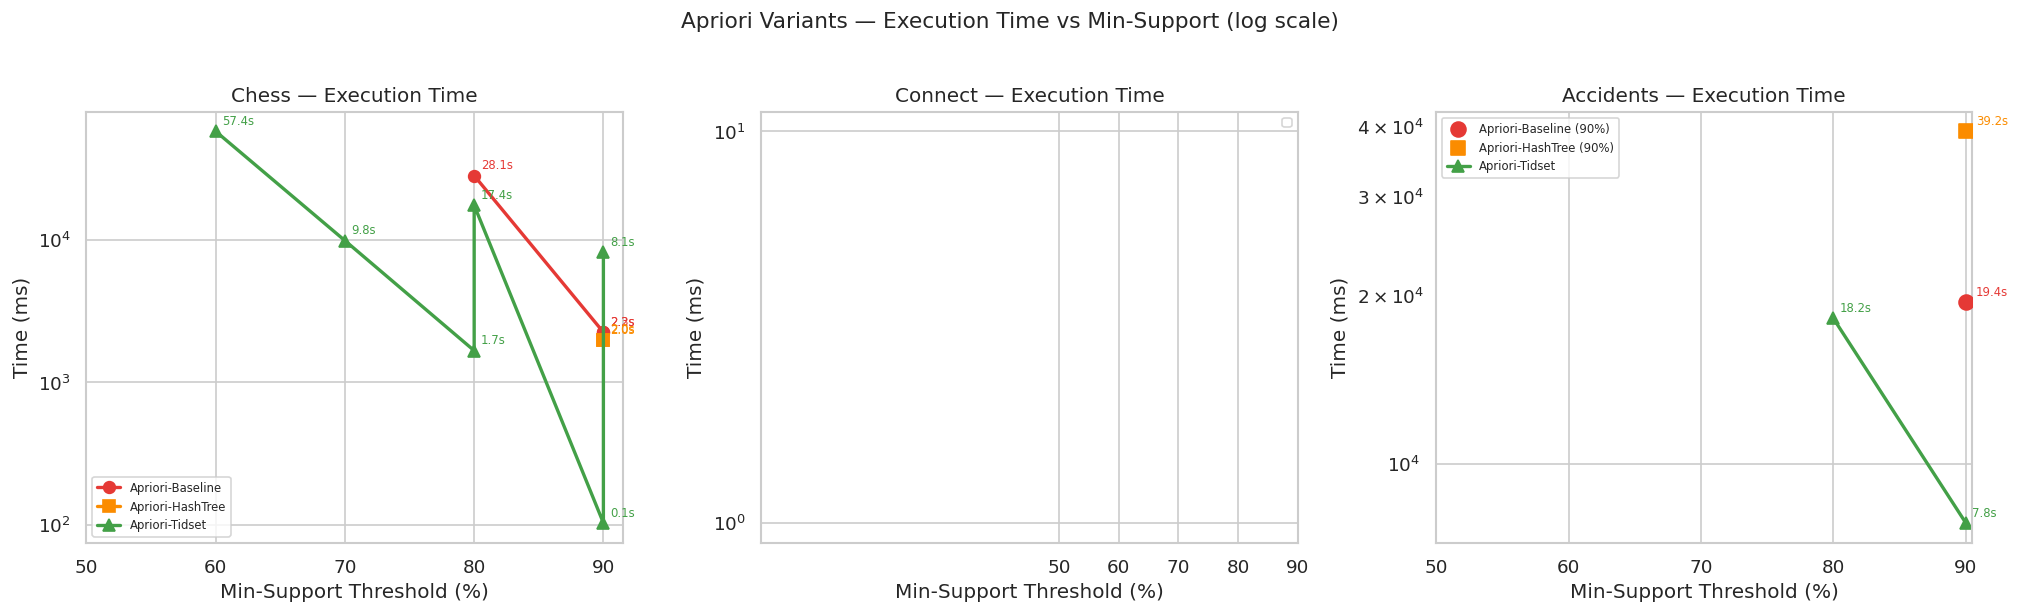

In [24]:
# ─── FIXED Plot 1: Execution Time ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.DataFrame(RESULTS)

algo_colors  = {'Apriori-Baseline':'#E53935',
                'Apriori-HashTree':'#FB8C00',
                'Apriori-Tidset':  '#43A047'}
algo_markers = {'Apriori-Baseline':'o',
                'Apriori-HashTree':'s',
                'Apriori-Tidset':  '^'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, ds_name in zip(axes, ['chess','connect','accidents']):
    sub = results_df[
        (results_df['Dataset']   == ds_name) &
        (results_df['timed_out'] == False)   &
        (results_df['time_ms'].notna())
    ]
    for algo in ['Apriori-Baseline','Apriori-HashTree','Apriori-Tidset']:
        d = sub[sub['Algorithm']==algo].sort_values('min_sup')
        if d.empty: continue
        x = d['min_sup'].values * 100
        y = d['time_ms'].values.astype(float)
        if len(x) == 1:
            # Single point — scatter with label
            ax.scatter(x, y, marker=algo_markers[algo],
                       color=algo_colors[algo], s=80, zorder=5,
                       label=f'{algo} ({x[0]:.0f}%)')
            ax.annotate(f'{y[0]/1000:.1f}s',
                        (x[0], y[0]), textcoords='offset points',
                        xytext=(6,4), fontsize=7, color=algo_colors[algo])
        else:
            ax.plot(x, y, marker=algo_markers[algo],
                    color=algo_colors[algo], linewidth=2,
                    markersize=7, label=algo)
            for xi, yi in zip(x, y):
                ax.annotate(f'{yi/1000:.1f}s', (xi, yi),
                            textcoords='offset points',
                            xytext=(4,4), fontsize=7,
                            color=algo_colors[algo])

    ax.set_title(f'{ds_name.capitalize()} — Execution Time')
    ax.set_xlabel('Min-Support Threshold (%)')
    ax.set_ylabel('Time (ms)')
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.set_xticks([50,60,70,80,90])

plt.suptitle('Apriori Variants — Execution Time vs Min-Support (log scale)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./data/nb2_time_vs_minsup.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_12705/3285901122.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


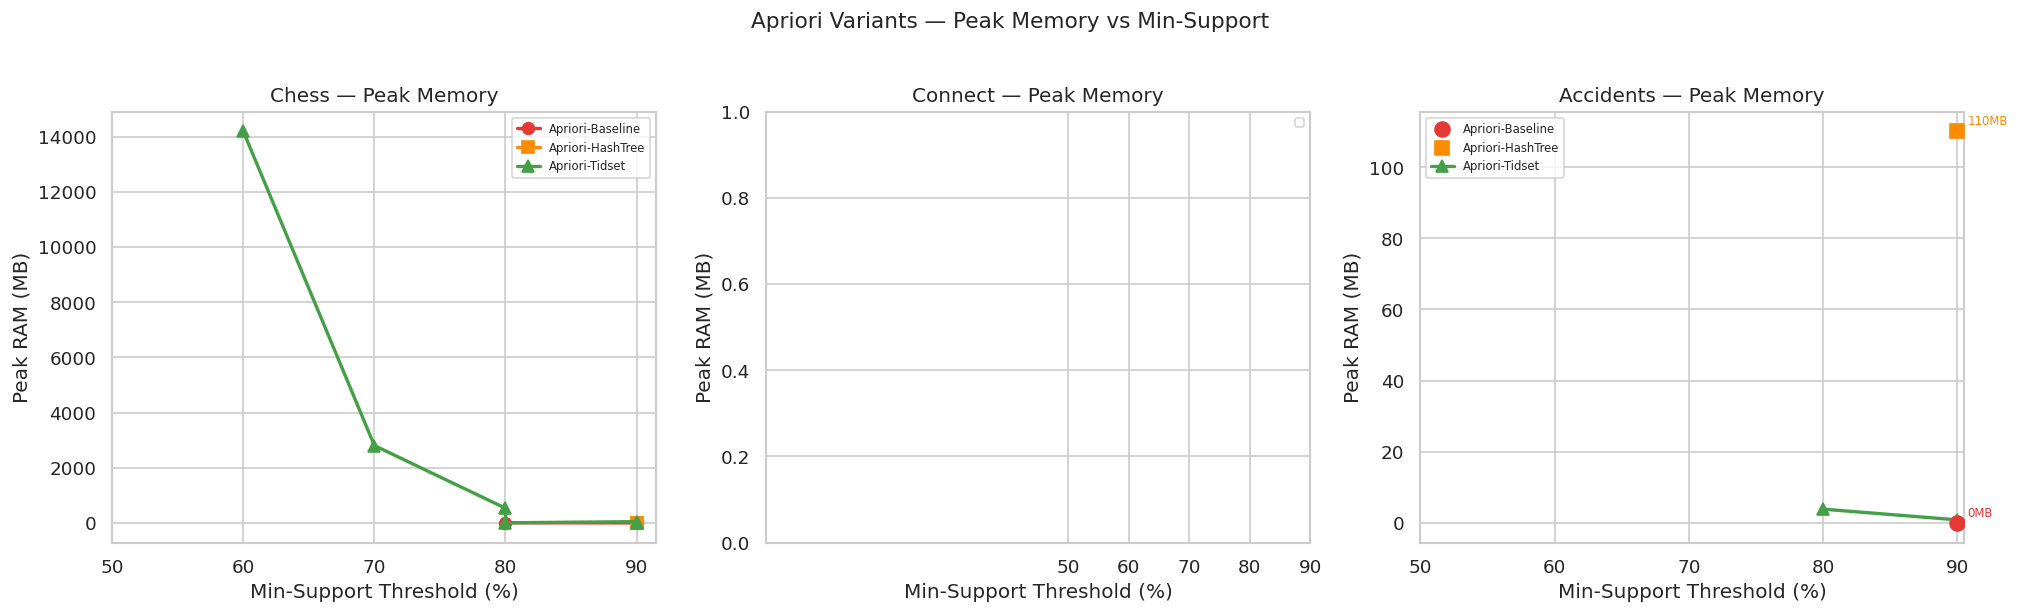

In [27]:
# ─── FIXED Plot 2: Memory ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, ds_name in zip(axes, ['chess','connect','accidents']):
    sub = results_df[
        (results_df['Dataset']   == ds_name) &
        (results_df['timed_out'] == False)   &
        (results_df['peak_mb'].notna())
    ]
    for algo in ['Apriori-Baseline','Apriori-HashTree','Apriori-Tidset']:
        d = sub[sub['Algorithm']==algo].sort_values('min_sup')
        if d.empty: continue
        x = d['min_sup'].values * 100
        y = d['peak_mb'].values.astype(float)
        if len(x) == 1:
            ax.scatter(x, y, marker=algo_markers[algo],
                       color=algo_colors[algo], s=80, zorder=5, label=algo)
            ax.annotate(f'{y[0]:.0f}MB', (x[0], y[0]),
                        textcoords='offset points',
                        xytext=(6,4), fontsize=7, color=algo_colors[algo])
        else:
            ax.plot(x, y, marker=algo_markers[algo],
                    color=algo_colors[algo], linewidth=2,
                    markersize=7, label=algo)

    ax.set_title(f'{ds_name.capitalize()} — Peak Memory')
    ax.set_xlabel('Min-Support Threshold (%)')
    ax.set_ylabel('Peak RAM (MB)')
    ax.legend(fontsize=7)
    ax.set_xticks([50,60,70,80,90])

plt.suptitle('Apriori Variants — Peak Memory vs Min-Support', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./data/nb2_memory_vs_minsup.png', bbox_inches='tight')
plt.show()

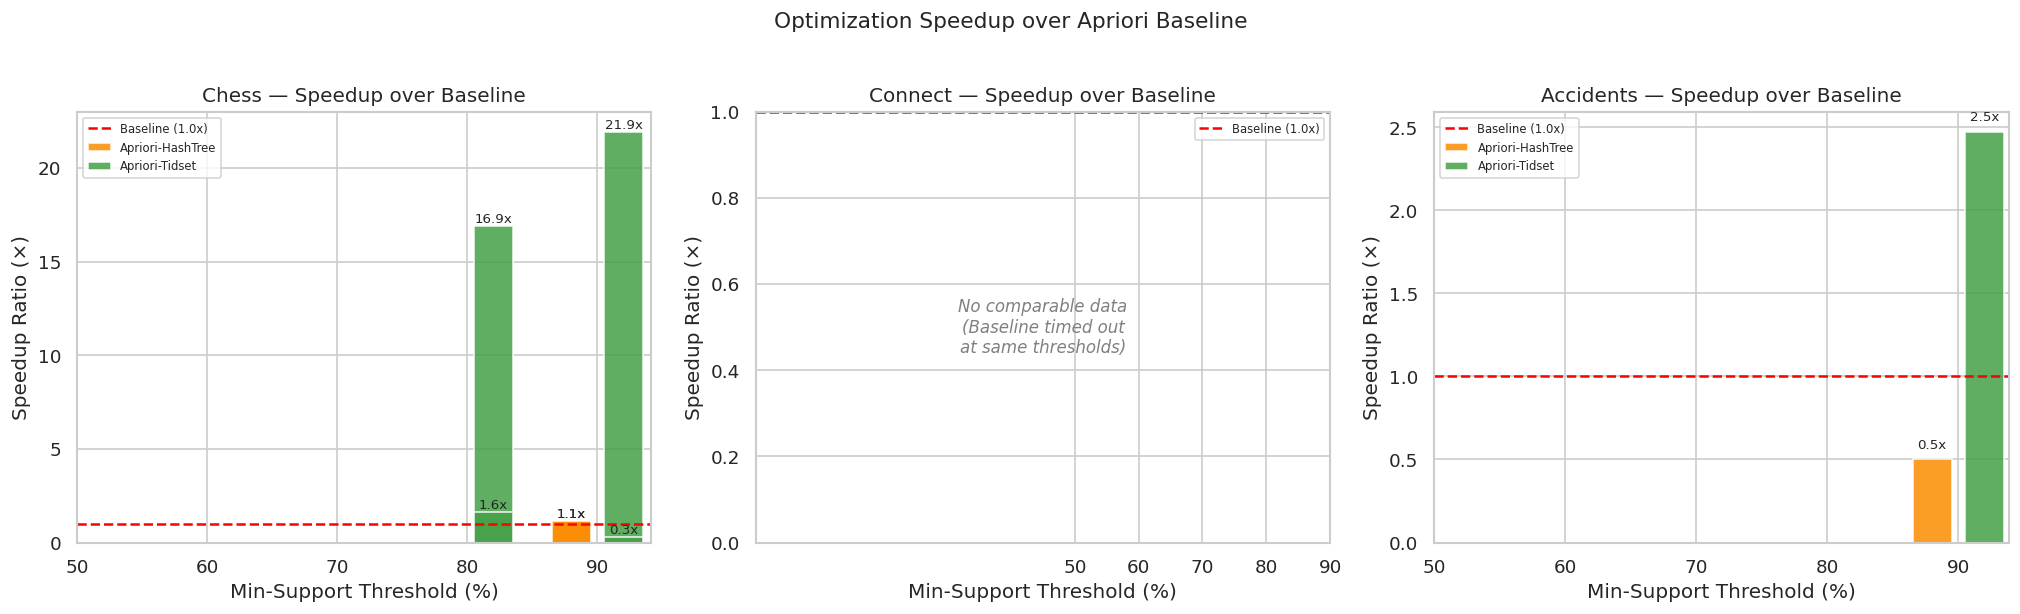

In [30]:
# ─── FIXED Plot 3: Speedup — computed in post-processing ──────────────────────
# Build baseline lookup first from collected results
baseline_lookup = {}
for _, row in results_df.iterrows():
    if row['Algorithm'] == 'Apriori-Baseline' and not row['timed_out']:
        baseline_lookup[(row['Dataset'], row['min_sup'])] = row['time_ms']

# Compute speedup for all rows
def get_speedup(row):
    if row['timed_out'] or row['time_ms'] is None:
        return None
    base = baseline_lookup.get((row['Dataset'], row['min_sup']))
    if base is None or row['time_ms'] == 0:
        return None
    return round(base / row['time_ms'], 2)

results_df['speedup_computed'] = results_df.apply(get_speedup, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, ds_name in zip(axes, ['chess','connect','accidents']):
    sub = results_df[
        (results_df['Dataset']   == ds_name) &
        (results_df['timed_out'] == False)   &
        (results_df['speedup_computed'].notna()) &
        (results_df['Algorithm'] != 'Apriori-Baseline')
    ]
    has_data = False
    for algo in ['Apriori-HashTree','Apriori-Tidset']:
        d = sub[sub['Algorithm']==algo].sort_values('min_sup')
        if d.empty: continue
        has_data = True
        x = d['min_sup'].values * 100
        y = d['speedup_computed'].values.astype(float)
        width = 3
        offset = 2 if algo == 'Apriori-Tidset' else -2
        bars = ax.bar(x + offset, y, width=width,
                      color=algo_colors[algo], label=algo, alpha=0.85)
        for bar, val in zip(bars, y):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05,
                    f'{val:.1f}x', ha='center', va='bottom', fontsize=8)

    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5,
               label='Baseline (1.0x)')
    ax.set_title(f'{ds_name.capitalize()} — Speedup over Baseline')
    ax.set_xlabel('Min-Support Threshold (%)')
    ax.set_ylabel('Speedup Ratio (×)')
    ax.legend(fontsize=7)
    ax.set_xticks([50,60,70,80,90])
    if not has_data:
        ax.text(0.5, 0.5, 'No comparable data\n(Baseline timed out\nat same thresholds)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray', style='italic')

plt.suptitle('Optimization Speedup over Apriori Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./data/nb2_speedup.png', bbox_inches='tight')
plt.show()

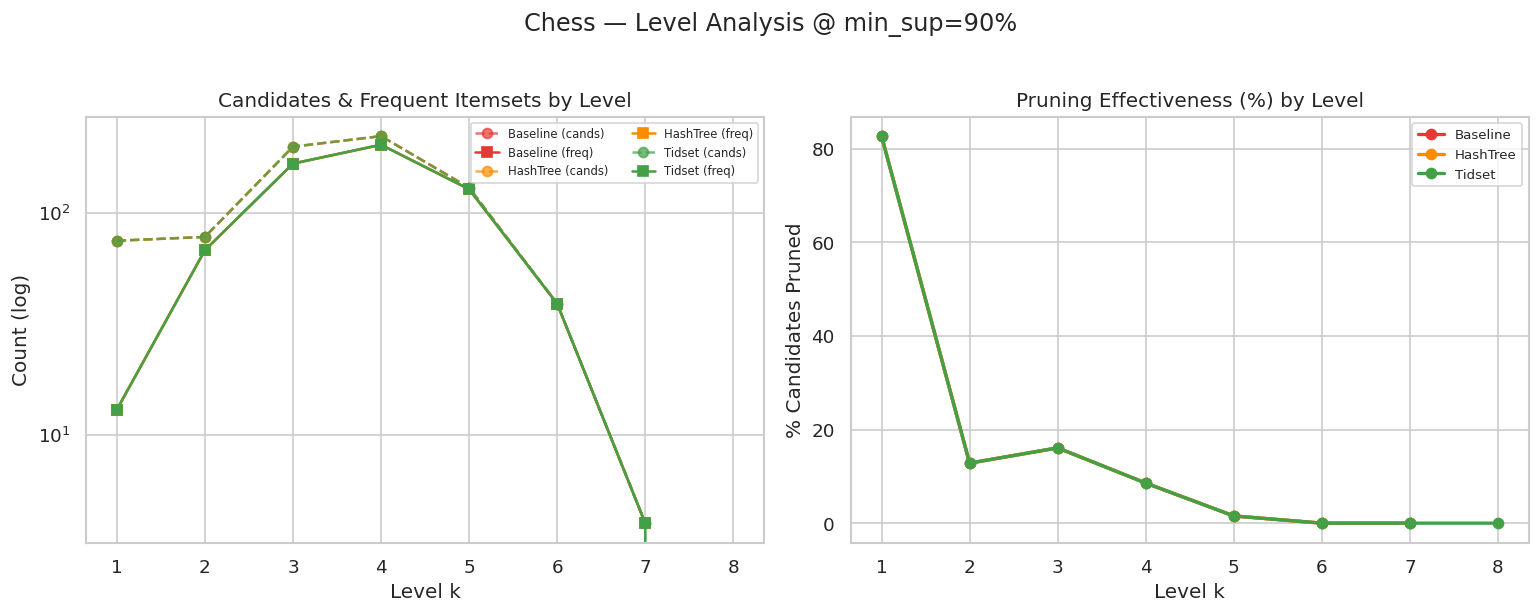

In [31]:
# ─── FIXED Plot 4: Level Analysis @ 90% (all three ran there) ─────────────────
LEVEL_THRESH = 0.90
chess_txns   = datasets['chess']
chess_vert   = vertical_datasets['chess']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name_algo, func, kwargs, color in [
    ('Baseline', apriori_baseline, {}, '#E53935'),
    ('HashTree', apriori_hashtree, {}, '#FB8C00'),
    ('Tidset',   apriori_tidset,
     {'prebuilt_vertical': chess_vert}, '#43A047'),
]:
    _, _, lvl = func(chess_txns, LEVEL_THRESH, **kwargs)
    ks    = [r[0] for r in lvl]
    cands = [r[1] for r in lvl]
    freqs = [r[2] for r in lvl]

    axes[0].plot(ks, cands, marker='o', color=color,
                 label=f'{name_algo} (cands)', linestyle='--', alpha=0.7)
    axes[0].plot(ks, freqs, marker='s', color=color,
                 label=f'{name_algo} (freq)', linestyle='-')

    pruning = [(1-f/c)*100 if c>0 else 0 for c,f in zip(cands,freqs)]
    axes[1].plot(ks, pruning, marker='o', color=color,
                 label=name_algo, linewidth=2)

axes[0].set_title('Candidates & Frequent Itemsets by Level')
axes[0].set_xlabel('Level k')
axes[0].set_ylabel('Count (log)')
axes[0].set_yscale('log')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_title('Pruning Effectiveness (%) by Level')
axes[1].set_xlabel('Level k')
axes[1].set_ylabel('% Candidates Pruned')
axes[1].legend(fontsize=8)

plt.suptitle(f'Chess — Level Analysis @ min_sup={LEVEL_THRESH:.0%}', y=1.02)
plt.tight_layout()
plt.savefig('./data/nb2_level_analysis.png', bbox_inches='tight')
plt.show()

---
## Section 10: Level-by-Level Analysis (Chess @ 0.80)

Shows the generate-and-test behaviour of Apriori level by level — key for the report's algorithmic analysis section.

Level-by-level statistics: Chess @ min_sup=80%

  Baseline
    k    Candidates    Frequent   Pruning %
    1            75          19       74.7%
    2           171         141       17.5%
    3           631         566       10.3%
    4         1,514       1,383        8.7%
    5         2,194       2,130        2.9%
    6         2,137       2,104        1.5%
    7         1,333       1,314        1.4%
    8           488         481        1.4%
    9            85          85        0.0%
   10             4           4        0.0%

  HashTree
    k    Candidates    Frequent   Pruning %
    1            75          19       74.7%
    2           171         141       17.5%
    3           631         566       10.3%
    4         1,514       1,383        8.7%
    5         2,194       2,130        2.9%
    6         2,137       2,104        1.5%
    7         1,333       1,314        1.4%
    8           488         481        1.4%
    9            85          85        0.0%
   10

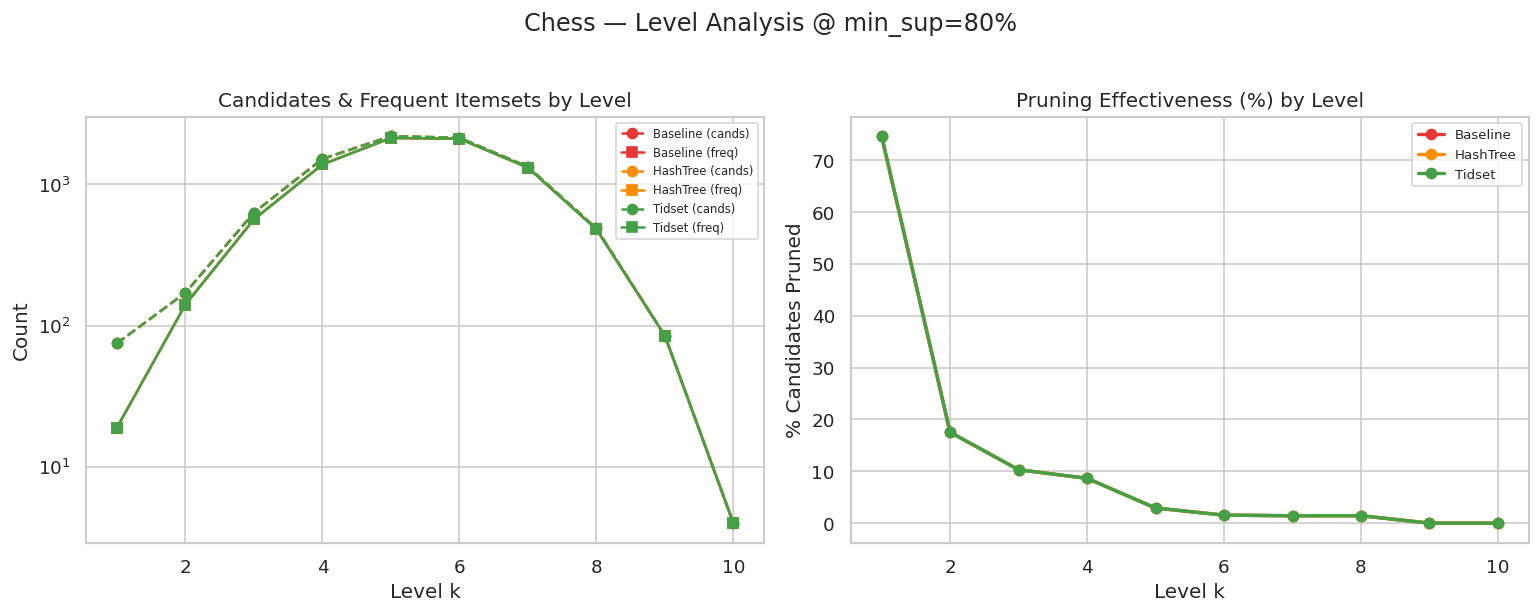

Figure saved: nb2_level_analysis.png


In [20]:
# ─── Level Statistics Analysis ────────────────────────────────────────────────

LEVEL_THRESH  = 0.80
chess_txns    = datasets['chess']
chess_vert    = vertical_datasets['chess']

print(f'Level-by-level statistics: Chess @ min_sup={LEVEL_THRESH:.0%}')
print()

for name_algo, func, kwargs in [
    ('Baseline', apriori_baseline, {}),
    ('HashTree', apriori_hashtree, {}),
    ('Tidset',   apriori_tidset,   {'prebuilt_vertical': chess_vert}),
]:
    _, _, lvl = func(chess_txns, LEVEL_THRESH, **kwargs)
    print(f'  {name_algo}')
    print(f'  {"k":>3}  {"Candidates":>12}  {"Frequent":>10}  {"Pruning %":>10}')
    for k, c_k, l_k in lvl:
        pruning = (1 - l_k / c_k) * 100 if c_k > 0 else 0
        print(f'  {k:>3}  {c_k:>12,}  {l_k:>10,}  {pruning:>9.1f}%')
    print()

# Visualize level stats
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name_algo, func, kwargs, color in [
    ('Baseline', apriori_baseline, {}, '#E53935'),
    ('HashTree', apriori_hashtree, {}, '#FB8C00'),
    ('Tidset',   apriori_tidset,   {'prebuilt_vertical': chess_vert}, '#43A047'),
]:
    _, _, lvl = func(chess_txns, LEVEL_THRESH, **kwargs)
    ks    = [r[0] for r in lvl]
    cands = [r[1] for r in lvl]
    freqs = [r[2] for r in lvl]
    axes[0].plot(ks, cands, marker='o', color=color, label=f'{name_algo} (cands)', linestyle='--')
    axes[0].plot(ks, freqs, marker='s', color=color, label=f'{name_algo} (freq)',  linestyle='-')
    axes[1].plot(ks,
                 [(1-f/c)*100 if c>0 else 0 for c,f in zip(cands,freqs)],
                 marker='o', color=color, label=name_algo, linewidth=2)

axes[0].set_title('Candidates & Frequent Itemsets by Level')
axes[0].set_xlabel('Level k')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].legend(fontsize=7)

axes[1].set_title('Pruning Effectiveness (%) by Level')
axes[1].set_xlabel('Level k')
axes[1].set_ylabel('% Candidates Pruned')
axes[1].legend(fontsize=8)

plt.suptitle(f'Chess — Level Analysis @ min_sup={LEVEL_THRESH:.0%}', y=1.02)
plt.tight_layout()
plt.savefig('./data/nb2_level_analysis.png', bbox_inches='tight')
plt.show()
print('Figure saved: nb2_level_analysis.png')

---
## Section 11: Save Results for Notebook 4 (Comparison)

In [21]:
# ─── Save results ─────────────────────────────────────────────────────────────
SAVE_DIR = './data/processed'
os.makedirs(SAVE_DIR, exist_ok=True)

nb2_bundle = {
    'results_df':        results_df,
    'algo_colors':       algo_colors,
    'MIN_SUP_THRESHOLDS': MIN_SUP_THRESHOLDS,
}

bundle_path = os.path.join(SAVE_DIR, 'nb2_apriori_results.pkl')
with open(bundle_path, 'wb') as f:
    pickle.dump(nb2_bundle, f)

mb = os.path.getsize(bundle_path) / 1024**2
print(f'Notebook 2 results saved: {bundle_path} ({mb:.2f} MB)')
print(f'Total experiments run: {len(results_df)}')
print(f'Timed out / skipped: {results_df["timed_out"].sum()}')
print(f'Successful:          {(~results_df["timed_out"]).sum()}')
print()
print('NEXT → Run Notebook 3: FP-Growth (mlxtend) + ProbDF (2024)')

Notebook 2 results saved: ./data/processed/nb2_apriori_results.pkl (0.00 MB)
Total experiments run: 60
Timed out / skipped: 45
Successful:          15

NEXT → Run Notebook 3: FP-Growth (mlxtend) + ProbDF (2024)


In [22]:
import pickle
import os

# Define the Google Drive save path
DRIVE_SAVE_DIR = '/content/drive/MyDrive/CS378_FIM_Project'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

drive_bundle_path = os.path.join(DRIVE_SAVE_DIR, 'nb2_apriori_results_final.pkl')

# Bundle the important results and configuration
nb2_bundle = {
    'results_df': results_df,
    'algo_colors': algo_colors,
    'MIN_SUP_THRESHOLDS': MIN_SUP_THRESHOLDS,
    'RESULTS': RESULTS
}

# Pickle dump to Drive
with open(drive_bundle_path, 'wb') as f:
    pickle.dump(nb2_bundle, f)

file_size_mb = os.path.getsize(drive_bundle_path) / (1024 * 1024)
print(f'✅ Successfully saved all results to Drive!')
print(f'Path: {drive_bundle_path}')
print(f'Size: {file_size_mb:.2f} MB')


✅ Successfully saved all results to Drive!
Path: /content/drive/MyDrive/CS378_FIM_Project/nb2_apriori_results_final.pkl
Size: 0.01 MB


In [32]:
import shutil
import glob

# Find all plot images in the local data directory
PLOT_DIR = './data'
plot_files = glob.glob(os.path.join(PLOT_DIR, '*.png'))

copied_files = []
for plot_file in plot_files:
    filename = os.path.basename(plot_file)
    dest_path = os.path.join(DRIVE_SAVE_DIR, filename)
    shutil.copy2(plot_file, dest_path)
    copied_files.append(filename)

print(f'✅ Successfully copied {len(copied_files)} plots to Drive at {DRIVE_SAVE_DIR}:')
for f in copied_files:
    print(f'  - {f}')

✅ Successfully copied 5 plots to Drive at /content/drive/MyDrive/CS378_FIM_Project:
  - nb2_candidates_vs_frequent.png
  - nb2_memory_vs_minsup.png
  - nb2_level_analysis.png
  - nb2_time_vs_minsup.png
  - nb2_speedup.png
